In [1]:
import warnings
import time
import numpy as np
import polars as pl
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split

import optuna
from catboost import CatBoostClassifier

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# OPTUNA
import optuna

# XGBOOST
from xgboost import XGBClassifier

/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [ ]:
# ==========================================
# BLOQUE 1: PREPARACIÓN GLOBAL
# ==========================================
# 1. Forzamos la conversión a matriz plana (Evitar avisos de columnas)
X_train_np = np.array(X_full_train_np)
y_train_np = np.array(y_full_train)

# 2. Convertimos las etiquetas -1/1 a 0/1 (Vital para ciberseguridad)
y_train_01 = ((y_train_np + 1) // 2).astype(np.int8)

# ==========================================
# BLOQUE 2: FUNCIÓN OBJECTIVE
# ==========================================
def objective(trial):
    warnings.filterwarnings("ignore")
    
    # 2.1 Espacio de búsqueda (Nomenclatura CatBoost)
    iterations = trial.suggest_int("iterations", 50, 600, step=50)
    depth = trial.suggest_int("depth", 3, 10) 
    
    # 2.2 Configuración CV #
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    f1_scores = []
    latencies = [] 

    # 2.3 Bucle de Entrenamiento y Medición
    for train_idx, val_idx in skf.split(X_train_np, y_train_01):
        X_train_cv, X_val_cv = X_train_np[train_idx], X_train_np[val_idx]
        y_train_cv, y_val_cv = y_train_01[train_idx], y_train_01[val_idx]

        model = CatBoostClassifier(
            iterations=iterations,
            depth=depth,
            learning_rate=0.1,
            random_seed=42,
            
            # --- CONFIGURACIÓN CATBOOST ---
            logging_level='Silent', # Cero spam
            task_type="GPU",        # Uso de GPU
        )

        model.fit(X_train_cv, y_train_cv)

        # 1. Predecir y guardar Eficacia (F1)
        y_pred = model.predict(X_val_cv, task_type="CPU")
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))
        
        # 2. Medir Eficiencia (Latencia) DENTRO DEL FOLD
        subset = min(10000, len(X_val_cv))
        X_lat = X_val_cv[:subset]
        
        # Warm-up rápido
        _ = model.predict(X_lat[:500], task_type="CPU")
        
        rep_lat = []
        for _ in range(3):
            t0 = time.perf_counter()
            _ = model.predict(X_lat, task_type="CPU")
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)
            
        latencies.append(float(np.mean(rep_lat))) # Guardamos la media de este fold

    # 2.5 El Retorno
    avg_f1 = float(np.mean(f1_scores))
    avg_lat = float(np.mean(latencies)) # Media de todos los folds
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# ==========================================
# BLOQUE 3: EJECUCIÓN DEL ESTUDIO
# ==========================================
study = optuna.create_study(directions=["maximize", "minimize"], study_name="catboost_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con CatBoost (Aceleración GPU)...")
study.optimize(objective, n_trials=30)

# ==========================================
# BLOQUE 4: EXTRACCIÓN Y PARETO
# ==========================================
pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["iterations"], # Renombrado
            "max_depth": t.params["depth"],         # Renombrado
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("catboost_ton_trials_results_cv.csv")

print("\n✅ Resultados robustos guardados en 'catboost_ton_trials_results_cv.csv'")

[I 2026-04-29 21:24:27,496] A new study created in memory with name: catboost_ids_optimization


🚀 Iniciando barrido multiobjetivo con CatBoost (Aceleración GPU)...


[I 2026-04-29 21:24:37,910] Trial 0 finished with values: [0.9959709983994112, 0.0005685160829064747] and parameters: {'iterations': 250, 'depth': 10}.
[I 2026-04-29 21:24:41,117] Trial 1 finished with values: [0.9919674291403338, 0.0004501674013833205] and parameters: {'iterations': 150, 'depth': 3}.
[I 2026-04-29 21:24:47,460] Trial 2 finished with values: [0.9948560875590051, 0.0004737070004921407] and parameters: {'iterations': 500, 'depth': 4}.
[I 2026-04-29 21:24:57,281] Trial 3 finished with values: [0.9960281219039144, 0.0005466708001525452] and parameters: {'iterations': 450, 'depth': 8}.
[I 2026-04-29 21:25:12,128] Trial 4 finished with values: [0.9959703989684682, 0.0005828691355418414] and parameters: {'iterations': 550, 'depth': 9}.
[I 2026-04-29 21:25:15,276] Trial 5 finished with values: [0.9935345961740668, 0.0005390688679957141] and parameters: {'iterations': 100, 'depth': 5}.
[I 2026-04-29 21:25:20,024] Trial 6 finished with values: [0.9945603421810325, 0.000498180151


✅ Resultados robustos guardados en 'catboost_iot_trials_results_cv.csv'


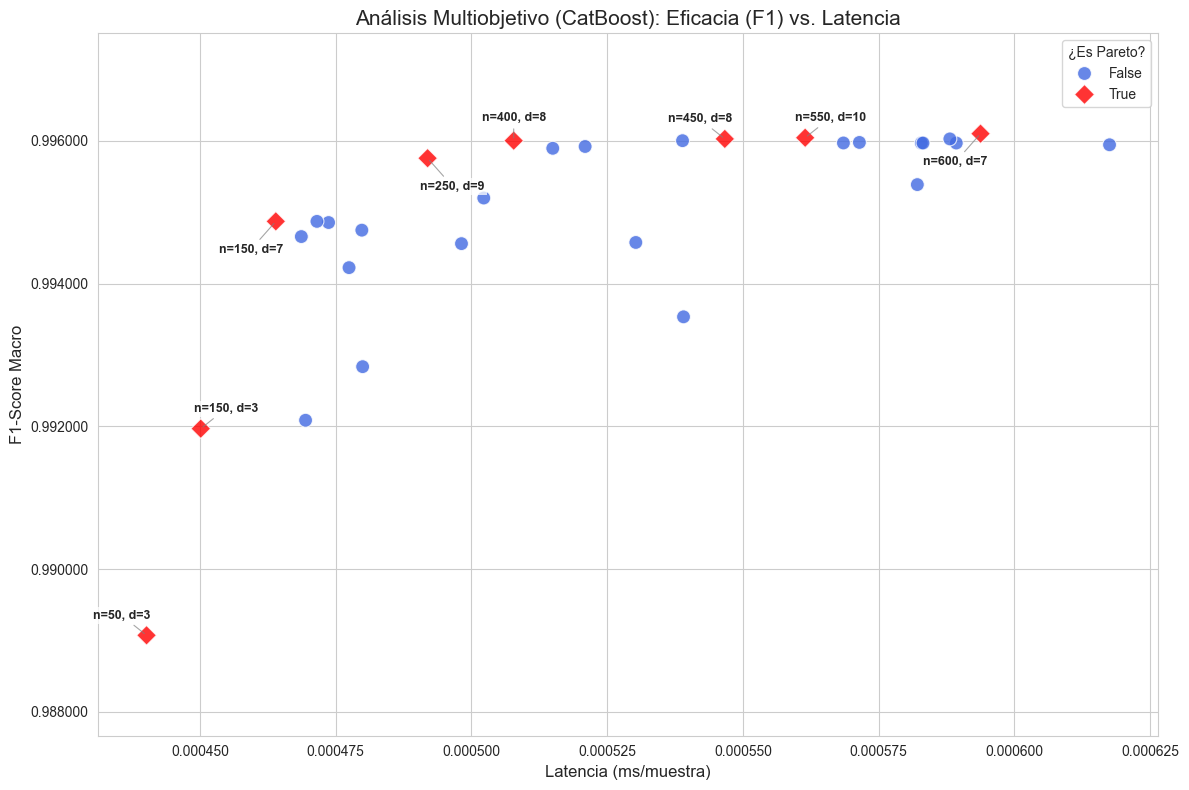

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FormatStrFormatter

# Leer los resultados guardados del estudio de CatBoost
df = pl.read_csv("catboost_ton_trials_results_cv.csv")
pareto_points = df.filter(pl.col("is_pareto") == True).sort("latency_ms")

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")
ax = plt.gca()

sns.scatterplot(
    x=df["latency_ms"].to_numpy(),
    y=df["f1_macro"].to_numpy(),
    hue=df["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"},
    s=100,
    alpha=0.8,
    ax=ax
)

# Evitamos el formato raro del eje Y cuando el F1 queda muy cerca de 1.0
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))

# Dejamos un pequeño margen vertical para que entren las etiquetas
y_vals = df["f1_macro"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.2, 0.00005)
    ax.set_ylim(y_min - margin, y_max + margin)

# Anotamos sólo los puntos Pareto, pegados a su marca
offsets = [(-18, 10), (18, 10), (-18, -16), (18, -16), (0, 12)]
for i, row in enumerate(pareto_points.iter_rows(named=True)):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_macro"]),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='center',
        va='bottom' if dy >= 0 else 'top',
        fontsize=9,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.7)
    )

plt.title("Análisis Multiobjetivo (CatBoost): Eficacia (F1) vs. Latencia", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.legend(title="¿Es Pareto?")
plt.tight_layout()
plt.show()


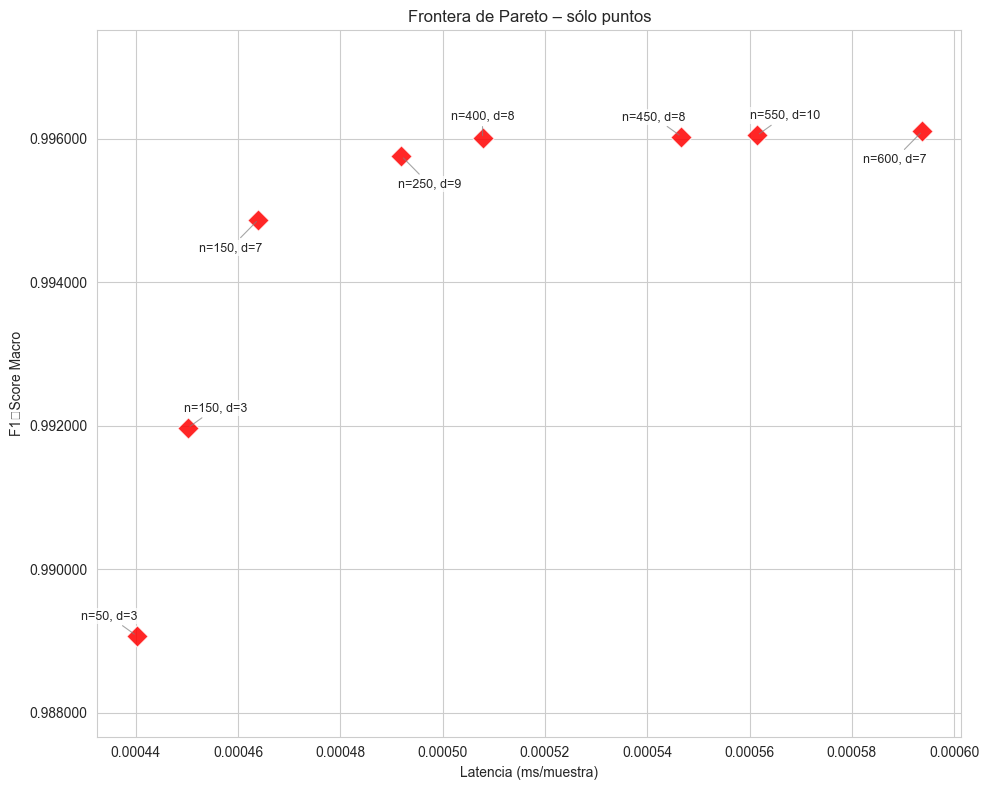

n_estimators=50, max_depth=3, f1_macro=0.989071, latency_ms=0.000440
n_estimators=150, max_depth=3, f1_macro=0.991967, latency_ms=0.000450
n_estimators=150, max_depth=7, f1_macro=0.994872, latency_ms=0.000464
n_estimators=250, max_depth=9, f1_macro=0.995757, latency_ms=0.000492
n_estimators=400, max_depth=8, f1_macro=0.996004, latency_ms=0.000508
n_estimators=450, max_depth=8, f1_macro=0.996028, latency_ms=0.000547
n_estimators=550, max_depth=10, f1_macro=0.996044, latency_ms=0.000561
n_estimators=600, max_depth=7, f1_macro=0.996102, latency_ms=0.000594


In [6]:
# graficar exclusivamente los puntos de la frontera de Pareto
from matplotlib.ticker import FormatStrFormatter

pareto_points = pareto_points.sort("latency_ms")

plt.figure(figsize=(10, 8))
sns.set_style("whitegrid")
ax = plt.gca()

sns.scatterplot(
    x=pareto_points["latency_ms"].to_numpy(),
    y=pareto_points["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.85,
    ax=ax
)

ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))

y_vals = pareto_points["f1_macro"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.2, 0.00005)
    ax.set_ylim(y_min - margin, y_max + margin)

offsets = [(-20, 10), (20, 10), (-20, -16), (20, -16), (0, 12)]
for i, row in enumerate(pareto_points.iter_rows(named=True)):
    dx, dy = offsets[i % len(offsets)]
    ax.annotate(
        f"n={int(row['n_estimators'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_macro"]),
        xytext=(dx, dy),
        textcoords='offset points',
        ha='center',
        va='bottom' if dy >= 0 else 'top',
        fontsize=9,
        bbox=dict(facecolor='white', alpha=0.75, edgecolor='none', pad=1.5),
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8, alpha=0.7)
    )

plt.title("Frontera de Pareto – sólo puntos")
plt.xlabel("Latencia (ms/muestra)")
plt.ylabel("F1‑Score Macro")
plt.tight_layout()
plt.show()

# Lista de puntos de Pareto
pareto_list = pareto_points.select(
    pl.col("n_estimators"),
    pl.col("max_depth"),
    pl.col("f1_macro"),
    pl.col("latency_ms")
).to_dicts()

for point in pareto_list:
    print(f"n_estimators={int(point['n_estimators'])}, max_depth={int(point['max_depth'])}, "
          f"f1_macro={point['f1_macro']:.6f}, latency_ms={point['latency_ms']:.6f}")

In [8]:
# ==========================================
# EVALUACIÓN FINAL EN TEST (5 CANDIDATOS CATBOOST)
# ==========================================

candidatos = [
    {"n": 50, "d": 3,   "nombre": "Candidato 1"},
    {"n": 150, "d": 3,   "nombre": "Candidato 2"},
    {"n": 150, "d": 7,   "nombre": "Candidato 3"},
    {"n": 250, "d": 9,   "nombre": "Candidato 4"},
    {"n": 400, "d": 8,  "nombre": "Candidato 5"},
    {"n": 450, "d": 8,  "nombre": "Candidato 6"},
    {"n": 550, "d": 10,  "nombre": "Candidato 7"},
    {"n": 600, "d": 7,  "nombre": "Candidato 8"},
]

resultados_finales = []

print("--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (CatBoost) ---\n")

# 1. Aseguramos que todo sea NumPy para evitar warnings
X_train_np = np.array(X_full_train_np)
X_test_np_arr = np.array(X_test_np)

# 2. Convertimos y_train/y_test a 0/1 para métricas binarias correctas
y_full_train01 = ((np.array(y_full_train) + 1) // 2).astype(np.int8)
y_test_np01    = ((np.array(y_test_np) + 1) // 2).astype(np.int8)

for c in candidatos:
    print(f"Probando: {c['nombre']} (n={c['n']}, d={c['d']})...")

    # 3. Inicializamos modelo
    # n_estimators en CatBoost es iterations | max_depth es depth
    model = CatBoostClassifier(
            iterations=c["n"],
            depth=c["d"],
            learning_rate=0.1,
            random_seed=42,
            
            # --- Configuración Específica CatBoost ---
            logging_level='Silent',     # Nada de spam en consola
            task_type="GPU",            # Entrenar en GPU a toda pastilla
    )

    # 4. Entrenamiento (con todos los datos de Train)
    model.fit(X_train_np, y_full_train01)

    # Forzamos inferencia en CPU para medir latencia real de produccion
    # Warm-up (despertar cachés del procesador)
    _ = model.predict(X_test_np_arr[:min(1000, len(X_test_np_arr))], task_type="CPU")

    # 5. Medición en el Set de Test (nunca visto por el modelo)
    t0 = time.perf_counter()
    y_pred01 = model.predict(X_test_np_arr, task_type="CPU")
    t1 = time.perf_counter()

    # 6. Cálculo de métricas
    tiempo_total = t1 - t0
    latencia = (tiempo_total / len(y_test_np01)) * 1000 # ms por muestra
    
    f1_test = f1_score(y_test_np01, y_pred01, average="macro")
    acc_test = accuracy_score(y_test_np01, y_pred01)

    # 7. Guardado de resultados
    resultados_finales.append({
        "Perfil": c["nombre"],
        "n_estimators": c["n"],
        "max_depth": c["d"],
        "F1_Test": float(f1_test),
        "Accuracy_Test": float(acc_test),
        "Latencia_ms": float(latencia)
    })

# 8. Creación de la tabla final
df_final = pl.DataFrame(resultados_finales)
print("\n" + "="*70)
print("              TABLA COMPARATIVA FINAL (CatBoost)")
print("="*70)
print(df_final)

--- EVALUACIÓN FINAL SOBRE EL SET DE TEST (CatBoost) ---

Probando: Candidato 1 (n=50, d=3)...
Probando: Candidato 2 (n=150, d=3)...
Probando: Candidato 3 (n=150, d=7)...
Probando: Candidato 4 (n=250, d=9)...
Probando: Candidato 5 (n=400, d=8)...
Probando: Candidato 6 (n=450, d=8)...
Probando: Candidato 7 (n=550, d=10)...
Probando: Candidato 8 (n=600, d=7)...

              TABLA COMPARATIVA FINAL (CatBoost)
shape: (8, 6)
┌─────────────┬──────────────┬───────────┬──────────┬───────────────┬─────────────┐
│ Perfil      ┆ n_estimators ┆ max_depth ┆ F1_Test  ┆ Accuracy_Test ┆ Latencia_ms │
│ ---         ┆ ---          ┆ ---       ┆ ---      ┆ ---           ┆ ---         │
│ str         ┆ i64          ┆ i64       ┆ f64      ┆ f64           ┆ f64         │
╞═════════════╪══════════════╪═══════════╪══════════╪═══════════════╪═════════════╡
│ Candidato 1 ┆ 50           ┆ 3         ┆ 0.98919  ┆ 0.992205      ┆ 0.000274    │
│ Candidato 2 ┆ 150          ┆ 3         ┆ 0.992427 ┆ 0.994527      ┆ 